# Forecasting Bitcoin Prices: A Comparative Analysis of Time-Series and Machine Learning Models

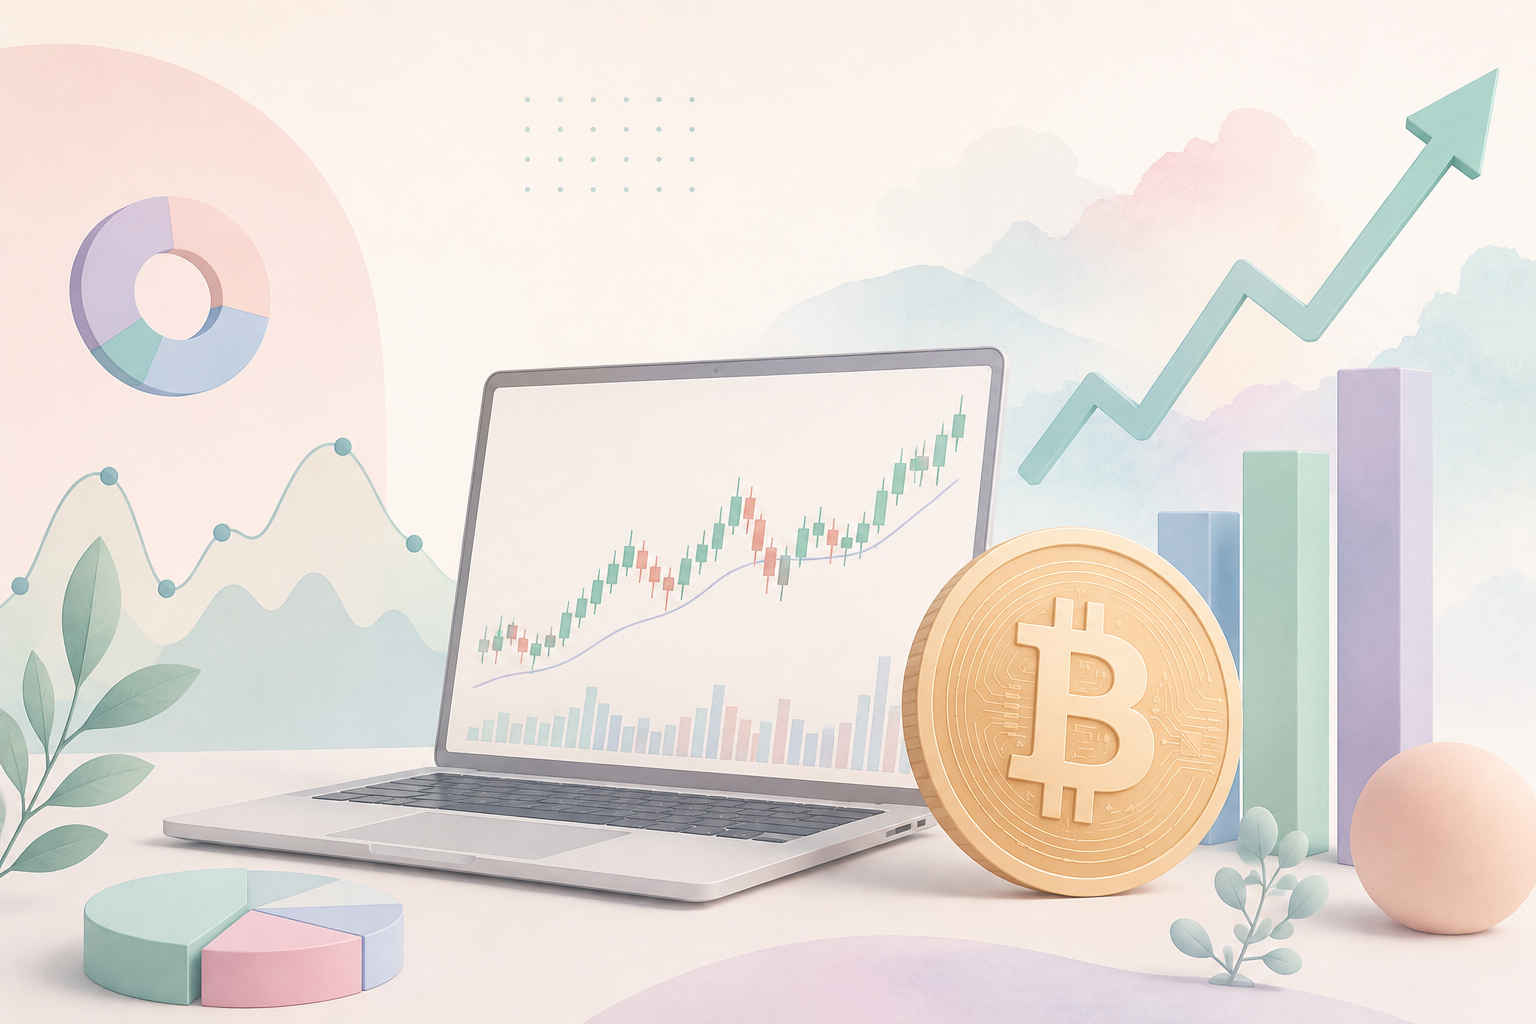

## Table of contents:

1. Introduction
2. Preliminary Data Inspection & Preprocessing

### 1. Introduction

About: Using historical BTC-USD data, the project follows a complete forecasting pipeline — from data preprocessing and exploratory analysis to feature engineering, model development, and performance evaluation. The project focuses on a comparative evaluation of time-series forecasting and machine learning models, with model performance assessed using Root Mean Squared Error (RMSE). The objective is not simply to generate a price forecast, but to investigate which modelling approach provides the most accurate predictions within the historical test period.

Models Used: ARIMA, SARIMA & Gradient Boosting

Evaluation: The models are evaluated on unseen chronological test data to avoid information from the future influencing model training. Performance is primarily measured using RMSE, with actual and predicted Bitcoin prices visualised to provide a clearer assessment of forecasting accuracy.

### 2. Preliminary Data Inspection & Preprocessing

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load Bitcoin historical data
df = pd.read_csv("/content/BTC-USD.csv")

In [4]:
# Display dataset dimensions
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset contains 3566 rows and 7 columns.


In [5]:
# view the first 5 rows
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,10-10-2014,364.687012,375.066986,352.963013,361.562012,361.562012,43665700.0
1,11-10-2014,361.362000,367.191010,355.950989,362.299011,362.299011,13345200.0
2,12-10-2014,362.605988,379.433014,356.144012,378.549011,378.549011,17552800.0
3,13-10-2014,377.920990,397.226013,368.897003,390.414001,390.414001,35221400.0
4,14-10-2014,391.691986,411.697998,391.324005,400.869995,400.869995,38491500.0


In [6]:
# Check data types
df.dtypes

,0
Date,object
Open,float64
High,float64
Low,float64
Close,float64
Adj Close,float64
Volume,float64


In [7]:
# Cover date's dtype from object to datetime (essential because the project involves time-series analysis and resampling)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [8]:
# Verify
df.dtypes

,0
Date,datetime64[ns]
Open,float64
High,float64
Low,float64
Close,float64
Adj Close,float64
Volume,float64


In [9]:
# Check date range
print("Start date:", df['Date'].min())
print("End date:", df['Date'].max())

Start date: 2014-10-10 00:00:00
End date: 2024-07-14 00:00:00


In [10]:
# Are the observations ordered chronologically?
df['Date'].is_monotonic_increasing

True

In [12]:
# Summary statistics
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,3566,2019-08-27 12:00:00.000000256,2014-10-10 00:00:00,2017-03-19 06:00:00,2019-08-27 12:00:00,2022-02-03 18:00:00,2024-07-14 00:00:00,NaN
Open,3566.0,17130.767783,176.897003,1164.660034,8940.442871,28084.279785,73079.375,18911.211338
High,3566.0,17521.648929,211.731003,1186.73996,9202.83252,28531.553713,73750.07031,19338.260241
Low,3566.0,16713.151782,171.509995,1126.907532,8790.986328,27534.169433,71334.09375,18441.412465
Close,3566.0,17146.361191,178.102997,1166.924988,8987.823243,28148.95947,73083.5,18920.806425
Adj Close,3566.0,17146.361191,178.102997,1166.924988,8987.823243,28148.95947,73083.5,18920.806425
Volume,3566.0,17462063967.589176,5914570.0,292893248.0,13632680969.5,28059118208.5,350968000000.0,19178470712.872845


In [13]:
# Check for missing values
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [14]:
# Check for duplicate observations
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [15]:
# Check for duplicate dates
print("Duplicate dates:", df['Date'].duplicated().sum())

Duplicate dates: 0


In [16]:
# Set date as the index

df = df.set_index('Date')

df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-10-10,364.687012,375.066986,352.963013,361.562012,361.562012,43665700.0
2014-10-11,361.362000,367.191010,355.950989,362.299011,362.299011,13345200.0
2014-10-12,362.605988,379.433014,356.144012,378.549011,378.549011,17552800.0
2014-10-13,377.920990,397.226013,368.897003,390.414001,390.414001,35221400.0
2014-10-14,391.691986,411.697998,391.324005,400.869995,400.869995,38491500.0


In [17]:
# Check the index
df.index

DatetimeIndex(['2014-10-10', '2014-10-11', '2014-10-12', '2014-10-13',
               '2014-10-14', '2014-10-15', '2014-10-16', '2014-10-17',
               '2014-10-18', '2014-10-19',
               ...
               '2024-07-05', '2024-07-06', '2024-07-07', '2024-07-08',
               '2024-07-09', '2024-07-10', '2024-07-11', '2024-07-12',
               '2024-07-13', '2024-07-14'],
              dtype='datetime64[ns]', name='Date', length=3566, freq=None)

In [18]:
# Check the observation frequency
df.index.to_series().diff().value_counts().head()

,count
Date,
1 days,3565


In [19]:
# Resampling to weekly data
weekly_df = df.resample('W').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Adj Close': 'last',
    'Volume': 'sum'
})

weekly_df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-10-12,364.687012,379.433014,352.963013,378.549011,378.549011,74563700.0
2014-10-19,377.920990,411.697998,368.897003,389.545990,389.545990,156902070.0
2014-10-26,389.230988,392.645996,342.877014,354.704010,354.704010,113691800.0
2014-11-02,354.777008,359.984009,320.626007,325.891998,325.891998,107075700.0
2014-11-09,325.569000,363.626007,325.076996,363.264008,363.264008,116793470.0


In [20]:
# Resampling to monthly data
monthly_df = df.resample('ME').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Adj Close': 'last',
    'Volume': 'sum'
})

monthly_df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-10-31,364.687012,411.697998,335.071991,338.321014,338.321014,4.269524e+08
2014-11-30,338.649994,457.092987,320.626007,378.046997,378.046997,6.597334e+08
2014-12-31,378.248993,384.037994,304.231995,320.192993,320.192993,5.531023e+08
2015-01-31,320.434998,320.434998,171.509995,217.464005,217.464005,1.098812e+09
2015-02-28,216.867004,265.610992,212.014999,254.263000,254.263000,7.115187e+08


In [21]:
# Resampling to quaterly data
quarterly_df = df.resample('QE').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Adj Close': 'last',
    'Volume': 'sum'
})

quarterly_df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-12-31,364.687012,457.092987,304.231995,320.192993,320.192993,1.639788e+09
2015-03-31,320.434998,320.434998,171.509995,244.223999,244.223999,2.769429e+09
2015-06-30,244.223007,267.867004,214.873993,263.071991,263.071991,1.870242e+09
2015-09-30,263.345001,314.394012,199.567001,236.059998,236.059998,2.508708e+09
2015-12-31,236.003998,495.562012,235.615997,430.566986,430.566986,5.227153e+09


In [22]:
# Compare the frequencies
print("Daily observations:", len(df))
print("Weekly observations:", len(weekly_df))
print("Monthly observations:", len(monthly_df))
print("Quarterly observations:", len(quarterly_df))

Daily observations: 3566
Weekly observations: 510
Monthly observations: 118
Quarterly observations: 40


The original dataset contains daily Bitcoin market observations. The data was additionally resampled to weekly, monthly and quarterly frequencies to examine Bitcoin price behaviour across different temporal horizons.

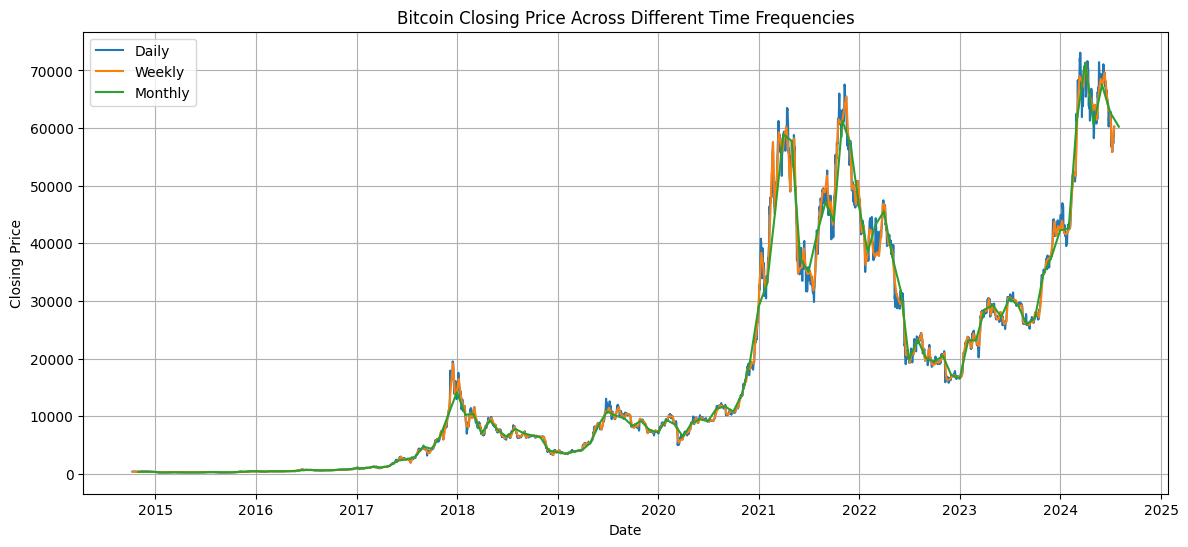

In [23]:
# Visualise the different frequencies
plt.figure(figsize=(14, 6))

plt.plot(df['Close'], label='Daily')
plt.plot(weekly_df['Close'], label='Weekly')
plt.plot(monthly_df['Close'], label='Monthly')

plt.title('Bitcoin Closing Price Across Different Time Frequencies')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.grid(True)

plt.show()